<a href="https://colab.research.google.com/github/Rafimsa/SnapBridg/blob/main/CODE_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_29795/3091616735.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


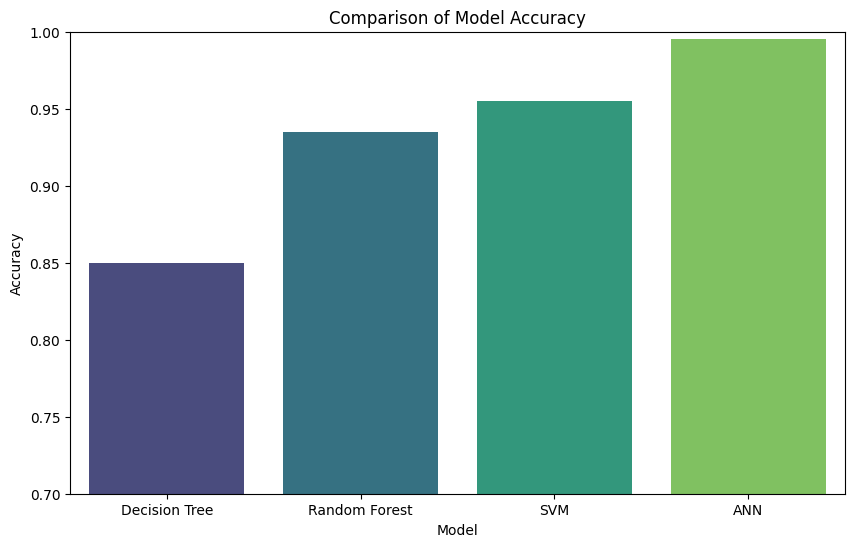

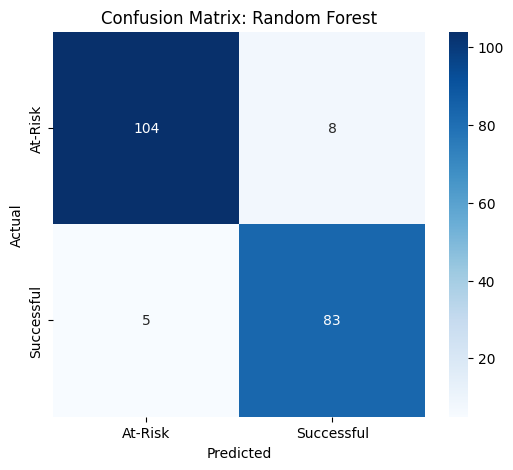

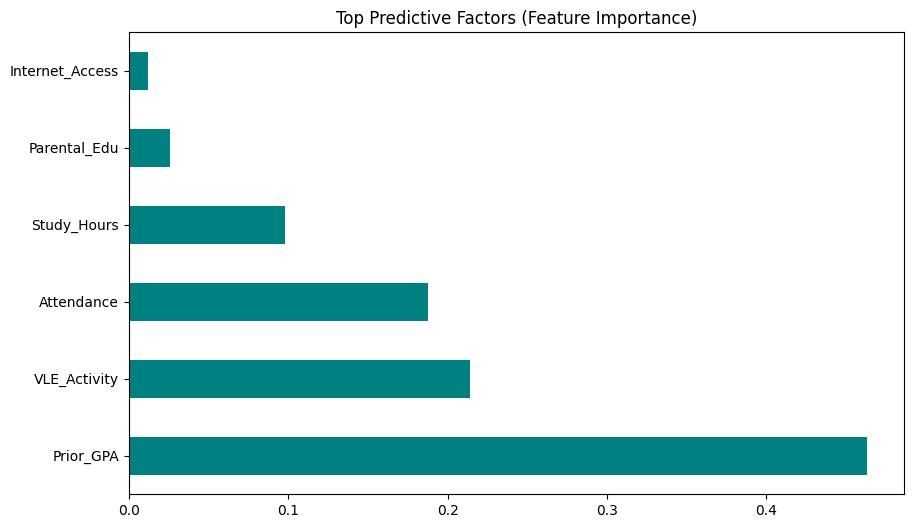

           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree     0.850   0.845238  0.806818  0.825581
1  Random Forest     0.935   0.912088  0.943182  0.927374
2            SVM     0.955   0.943820  0.954545  0.949153
3            ANN     0.995   1.000000  0.988636  0.994286


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Synthetic Dataset Generation (Mimicking OULAD/UCI Characteristics)
def generate_data(n_samples=1000):
    np.random.seed(42)
    data = {
        'Study_Hours': np.random.randint(1, 10, n_samples),
        'Attendance': np.random.randint(50, 100, n_samples),
        'Prior_GPA': np.random.uniform(2.0, 4.0, n_samples),
        'VLE_Activity': np.random.randint(10, 500, n_samples),
        'Parental_Edu': np.random.randint(0, 4, n_samples),
        'Internet_Access': np.random.choice([0, 1], n_samples)
    }
    df = pd.DataFrame(data)

    # Logic to create the target variable based on report's 'Importance' findings
    # Performance is heavily influenced by GPA and Attendance
    score = (df['Prior_GPA'] * 20) + (df['Attendance'] * 0.5) + (df['Study_Hours'] * 2) + (df['VLE_Activity'] * 0.05)
    df['Performance'] = pd.qcut(score, q=2, labels=['At-Risk', 'Successful'])
    return df

df = generate_data()

# 2. Data Preprocessing
le = LabelEncoder()
df['Performance'] = le.fit_transform(df['Performance']) # 0: At-Risk, 1: Successful

X = df.drop('Performance', axis=1)
y = df['Performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Implementation
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500)
}

results = []

# 4. Training and Evaluation
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

# 5. Visualizations
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Comparison of Model Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

# Confusion Matrix for the "Winner" (Random Forest)
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['At-Risk', 'Successful'], yticklabels=['At-Risk', 'Successful'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Predictive Factors (Feature Importance)')
plt.show()

print(results_df)